# Inspect Cleaned Ukrainian Word Dataset

Visual quality check: picks random writers, shows their word images at full resolution with labels.

In [8]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from collections import defaultdict
import matplotlib.pyplot as plt
from IPython.display import display, HTML

DATASET_ROOT = "/extra_space2/oles_new/UkrHandwritten_Words_UltraClean"
IMG_DIR = os.path.join(DATASET_ROOT, "words", "words")

df = pd.read_csv(os.path.join(DATASET_ROOT, "METAFILE.tsv"), sep="\t")
df["writer"] = df["filename"].apply(lambda x: x.split("-")[2])
print(f"Loaded {len(df):,} entries, {df['writer'].nunique()} writers")
print(f"Word length: {df['transcription'].str.len().min()}-{df['transcription'].str.len().max()} chars")
print(f"Samples/writer: min={df['writer'].value_counts().min()}, "
      f"max={df['writer'].value_counts().max()}, "
      f"median={df['writer'].value_counts().median():.0f}")

Loaded 12,840 entries, 158 writers
Word length: 4-22 chars
Samples/writer: min=30, max=413, median=51


## Writer Overview — Sample Distribution

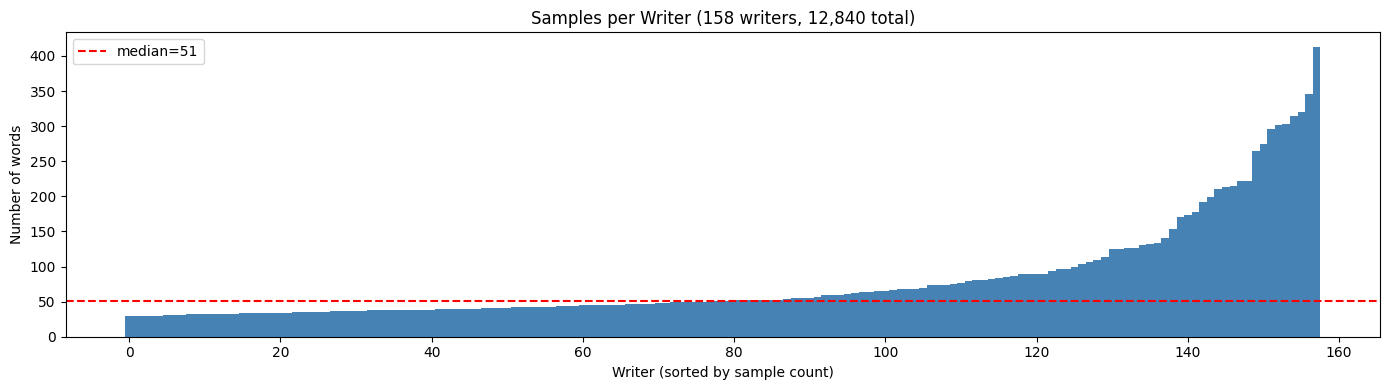

In [9]:
wc = df["writer"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(wc)), wc.values, width=1.0, color="steelblue")
ax.set_xlabel("Writer (sorted by sample count)")
ax.set_ylabel("Number of words")
ax.set_title(f"Samples per Writer ({len(wc)} writers, {len(df):,} total)")
ax.axhline(wc.median(), color="red", ls="--", label=f"median={wc.median():.0f}")
ax.legend()
plt.tight_layout()
plt.show()

## Visual Inspection — Random Writers

Shows 8 random words per writer for N_WRITERS random writers. Each image shown at full resolution.

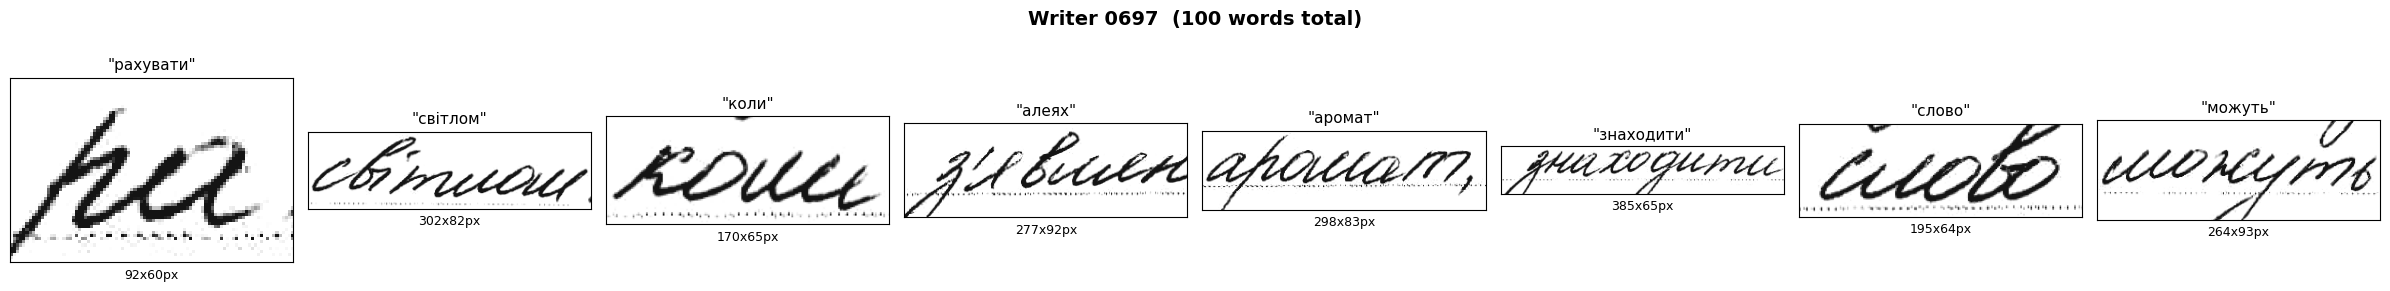

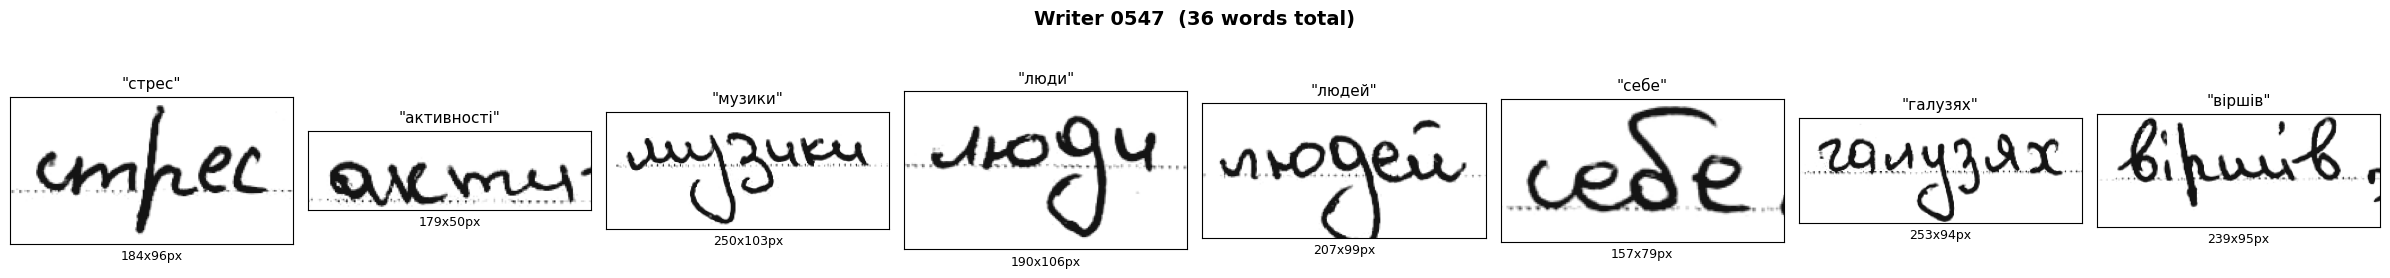

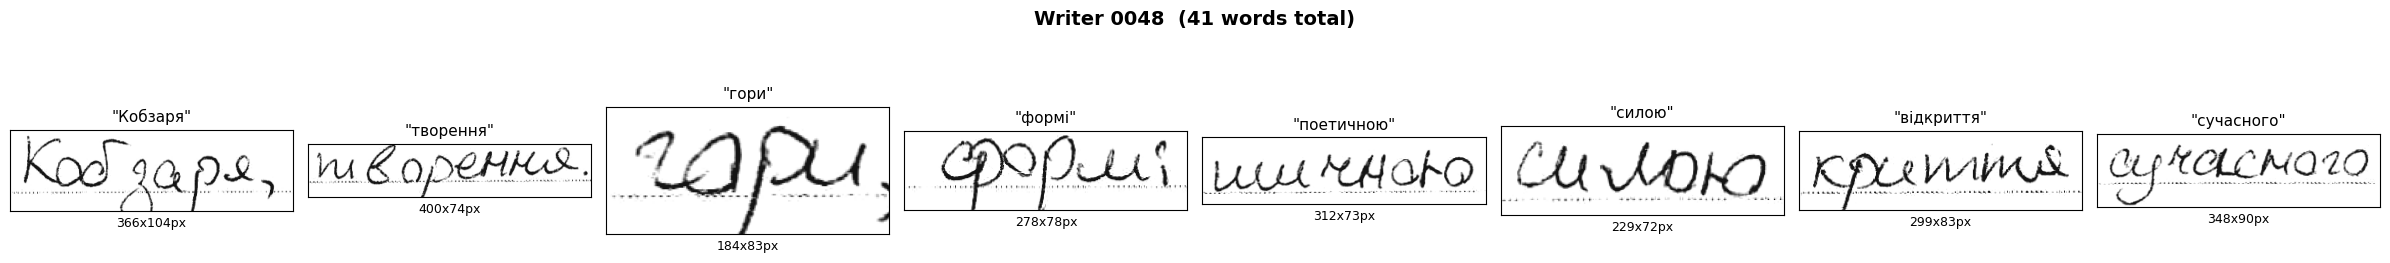

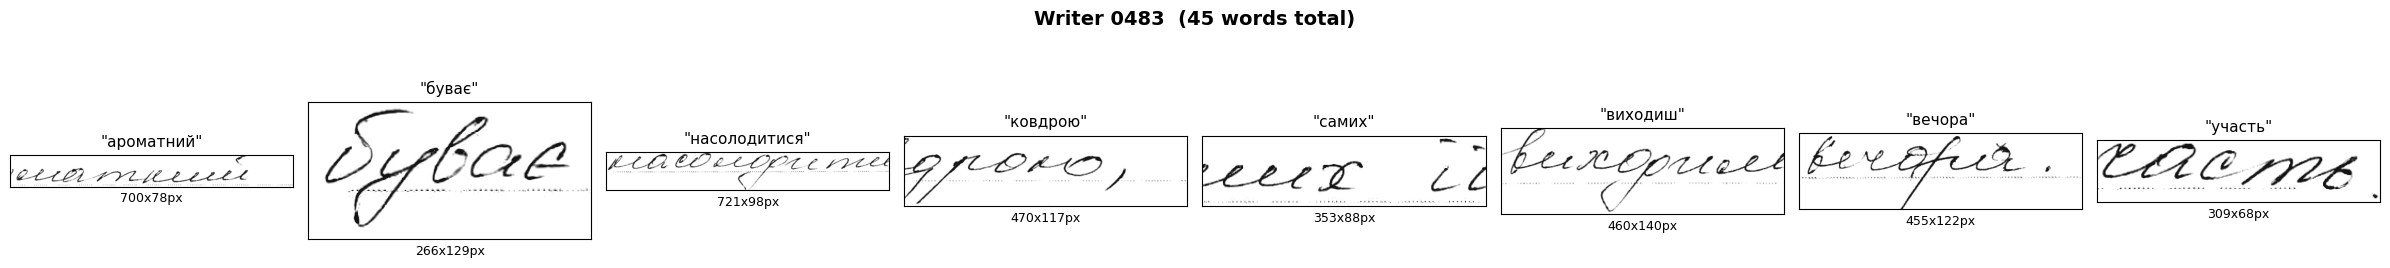

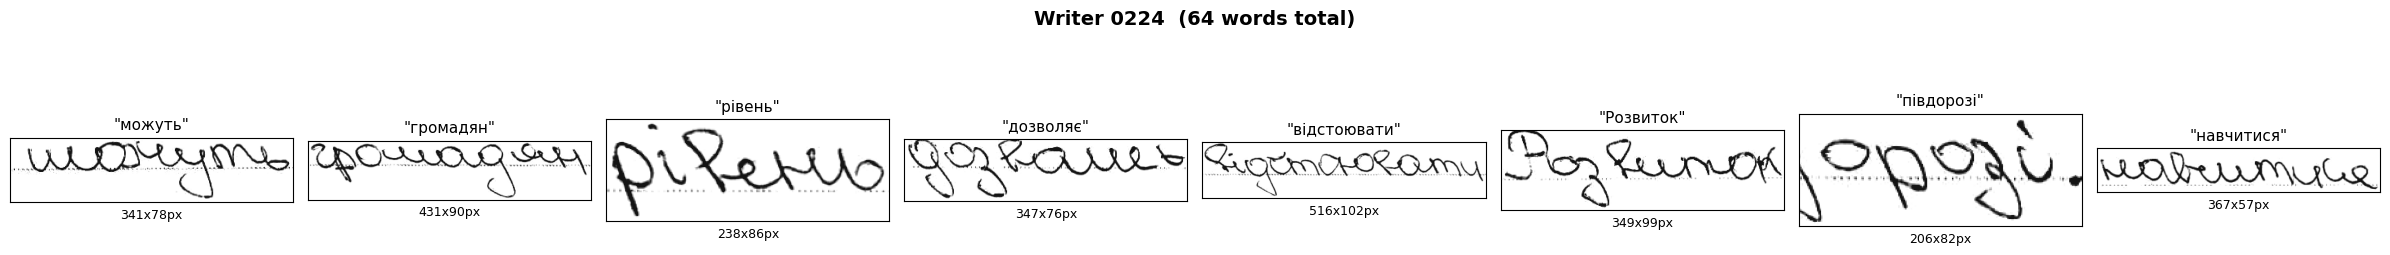

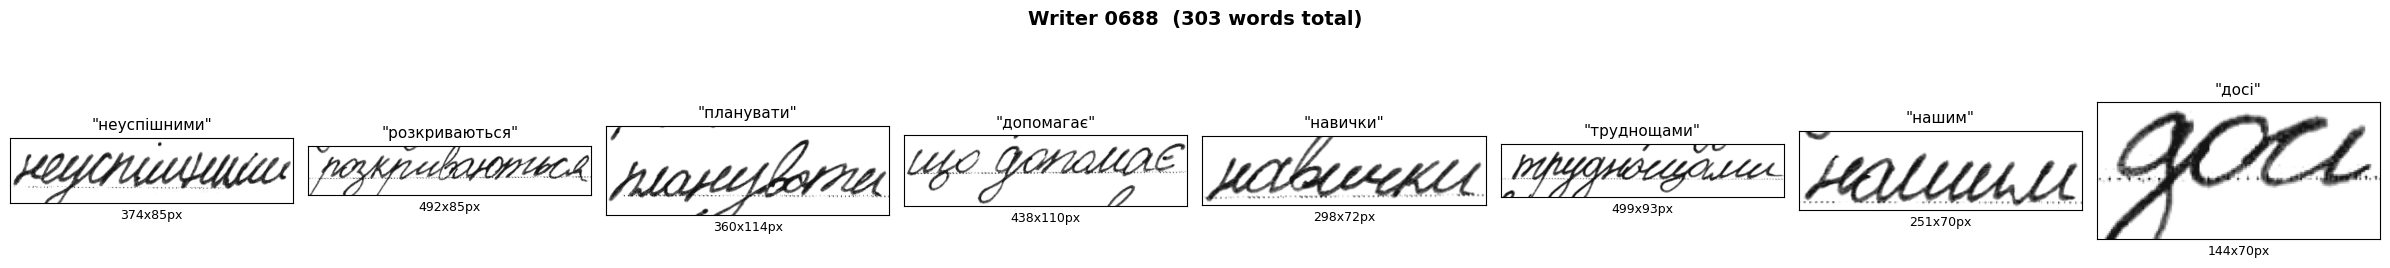

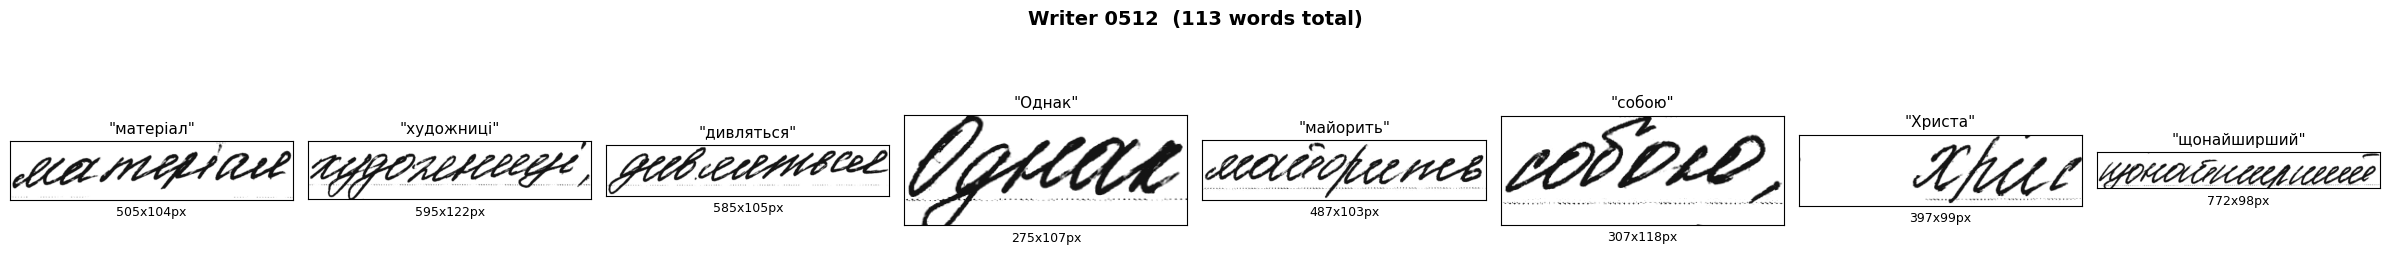

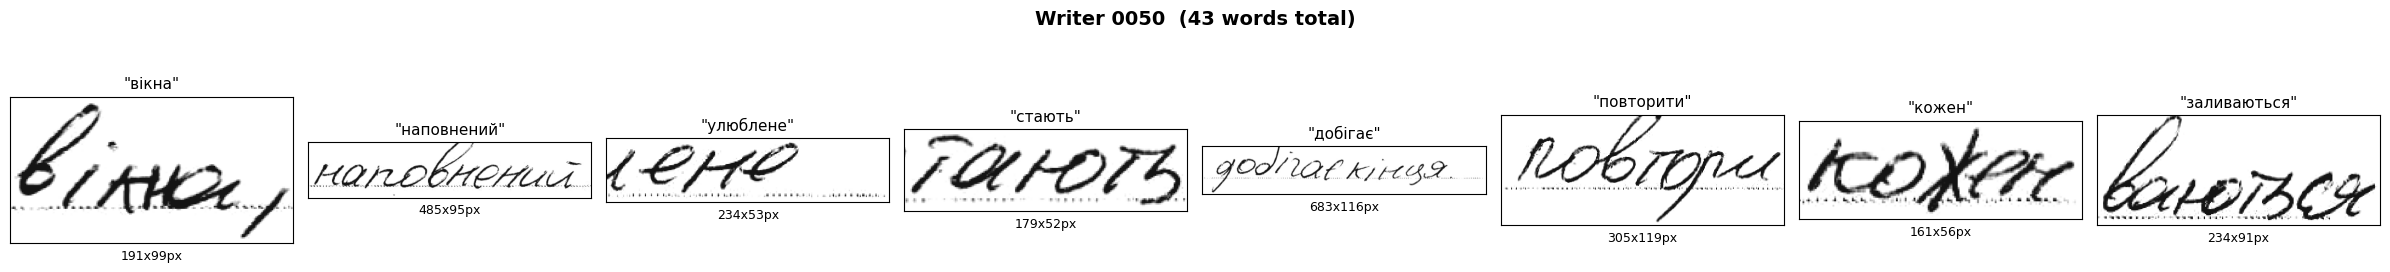

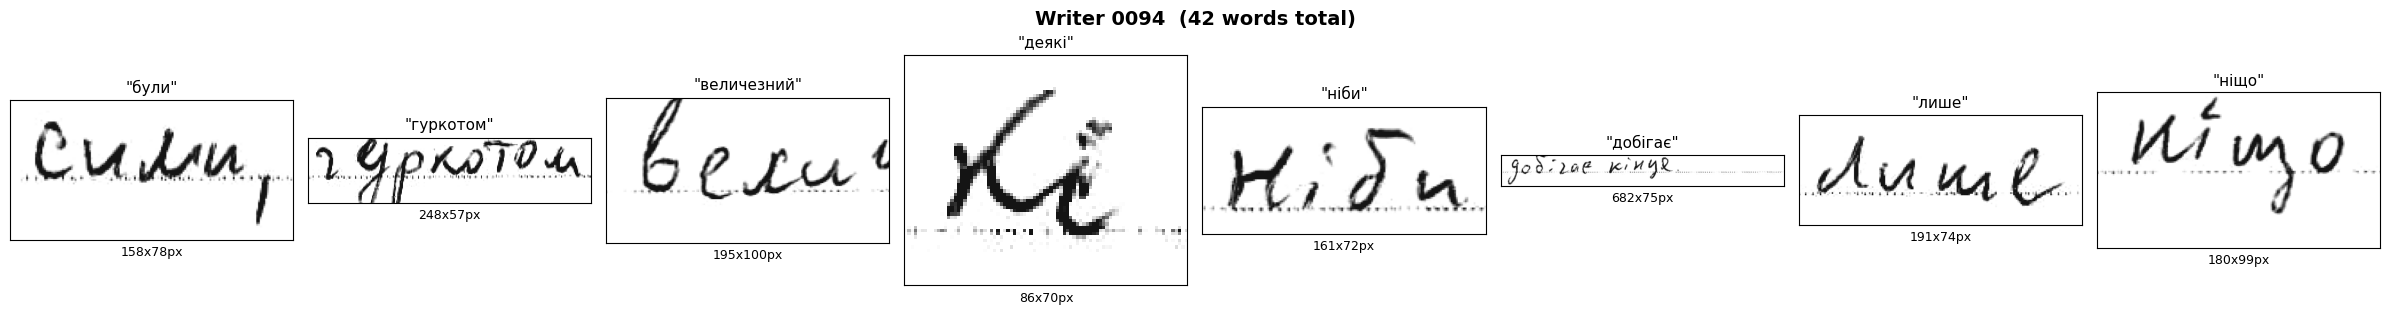

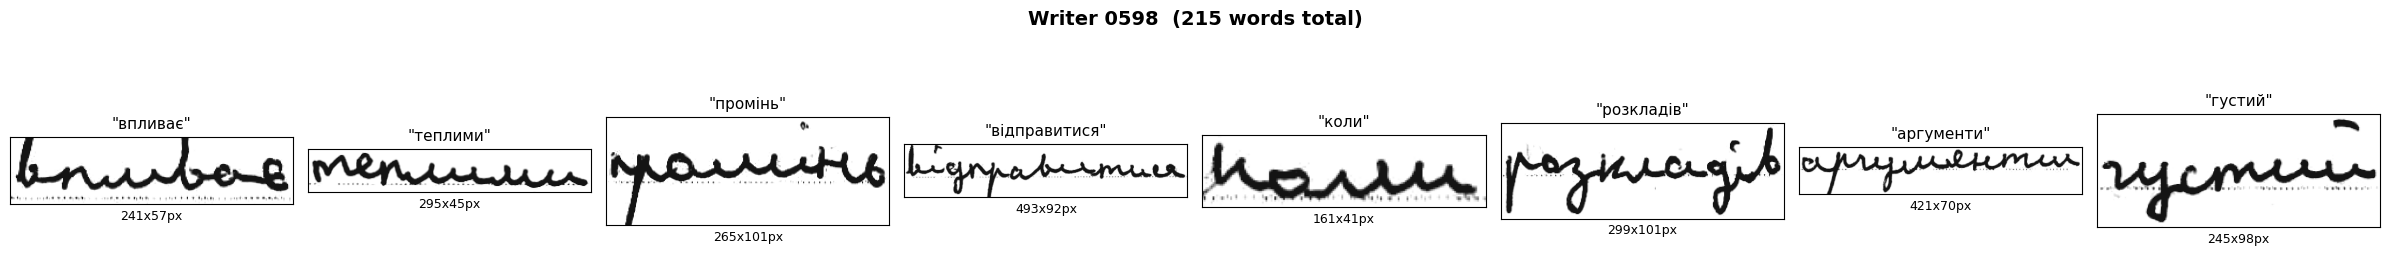

In [10]:
N_WRITERS = 10
WORDS_PER_WRITER = 8
SEED = 42

rng = np.random.default_rng(SEED)
all_writers = sorted(df["writer"].unique())
chosen = rng.choice(all_writers, size=min(N_WRITERS, len(all_writers)), replace=False)

for writer_id in chosen:
    subset = df[df["writer"] == writer_id]
    sample = subset.sample(n=min(WORDS_PER_WRITER, len(subset)), random_state=int(rng.integers(1e6)))

    fig, axes = plt.subplots(1, len(sample), figsize=(3 * len(sample), 3))
    if len(sample) == 1:
        axes = [axes]
    fig.suptitle(f"Writer {writer_id}  ({len(subset)} words total)", fontsize=14, fontweight="bold")

    for ax, (_, row) in zip(axes, sample.iterrows()):
        img_path = os.path.join(IMG_DIR, row["filename"])
        img = Image.open(img_path)
        ax.imshow(img, cmap="gray" if img.mode == "L" else None)
        ax.set_title(f'"{row["transcription"]}"', fontsize=11)
        ax.set_xlabel(f"{img.size[0]}x{img.size[1]}px", fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()
    plt.show()

## Spot-Check: Specific Writer

Set `CHECK_WRITER` to any writer ID (4-digit string from the list above) to see all their words.

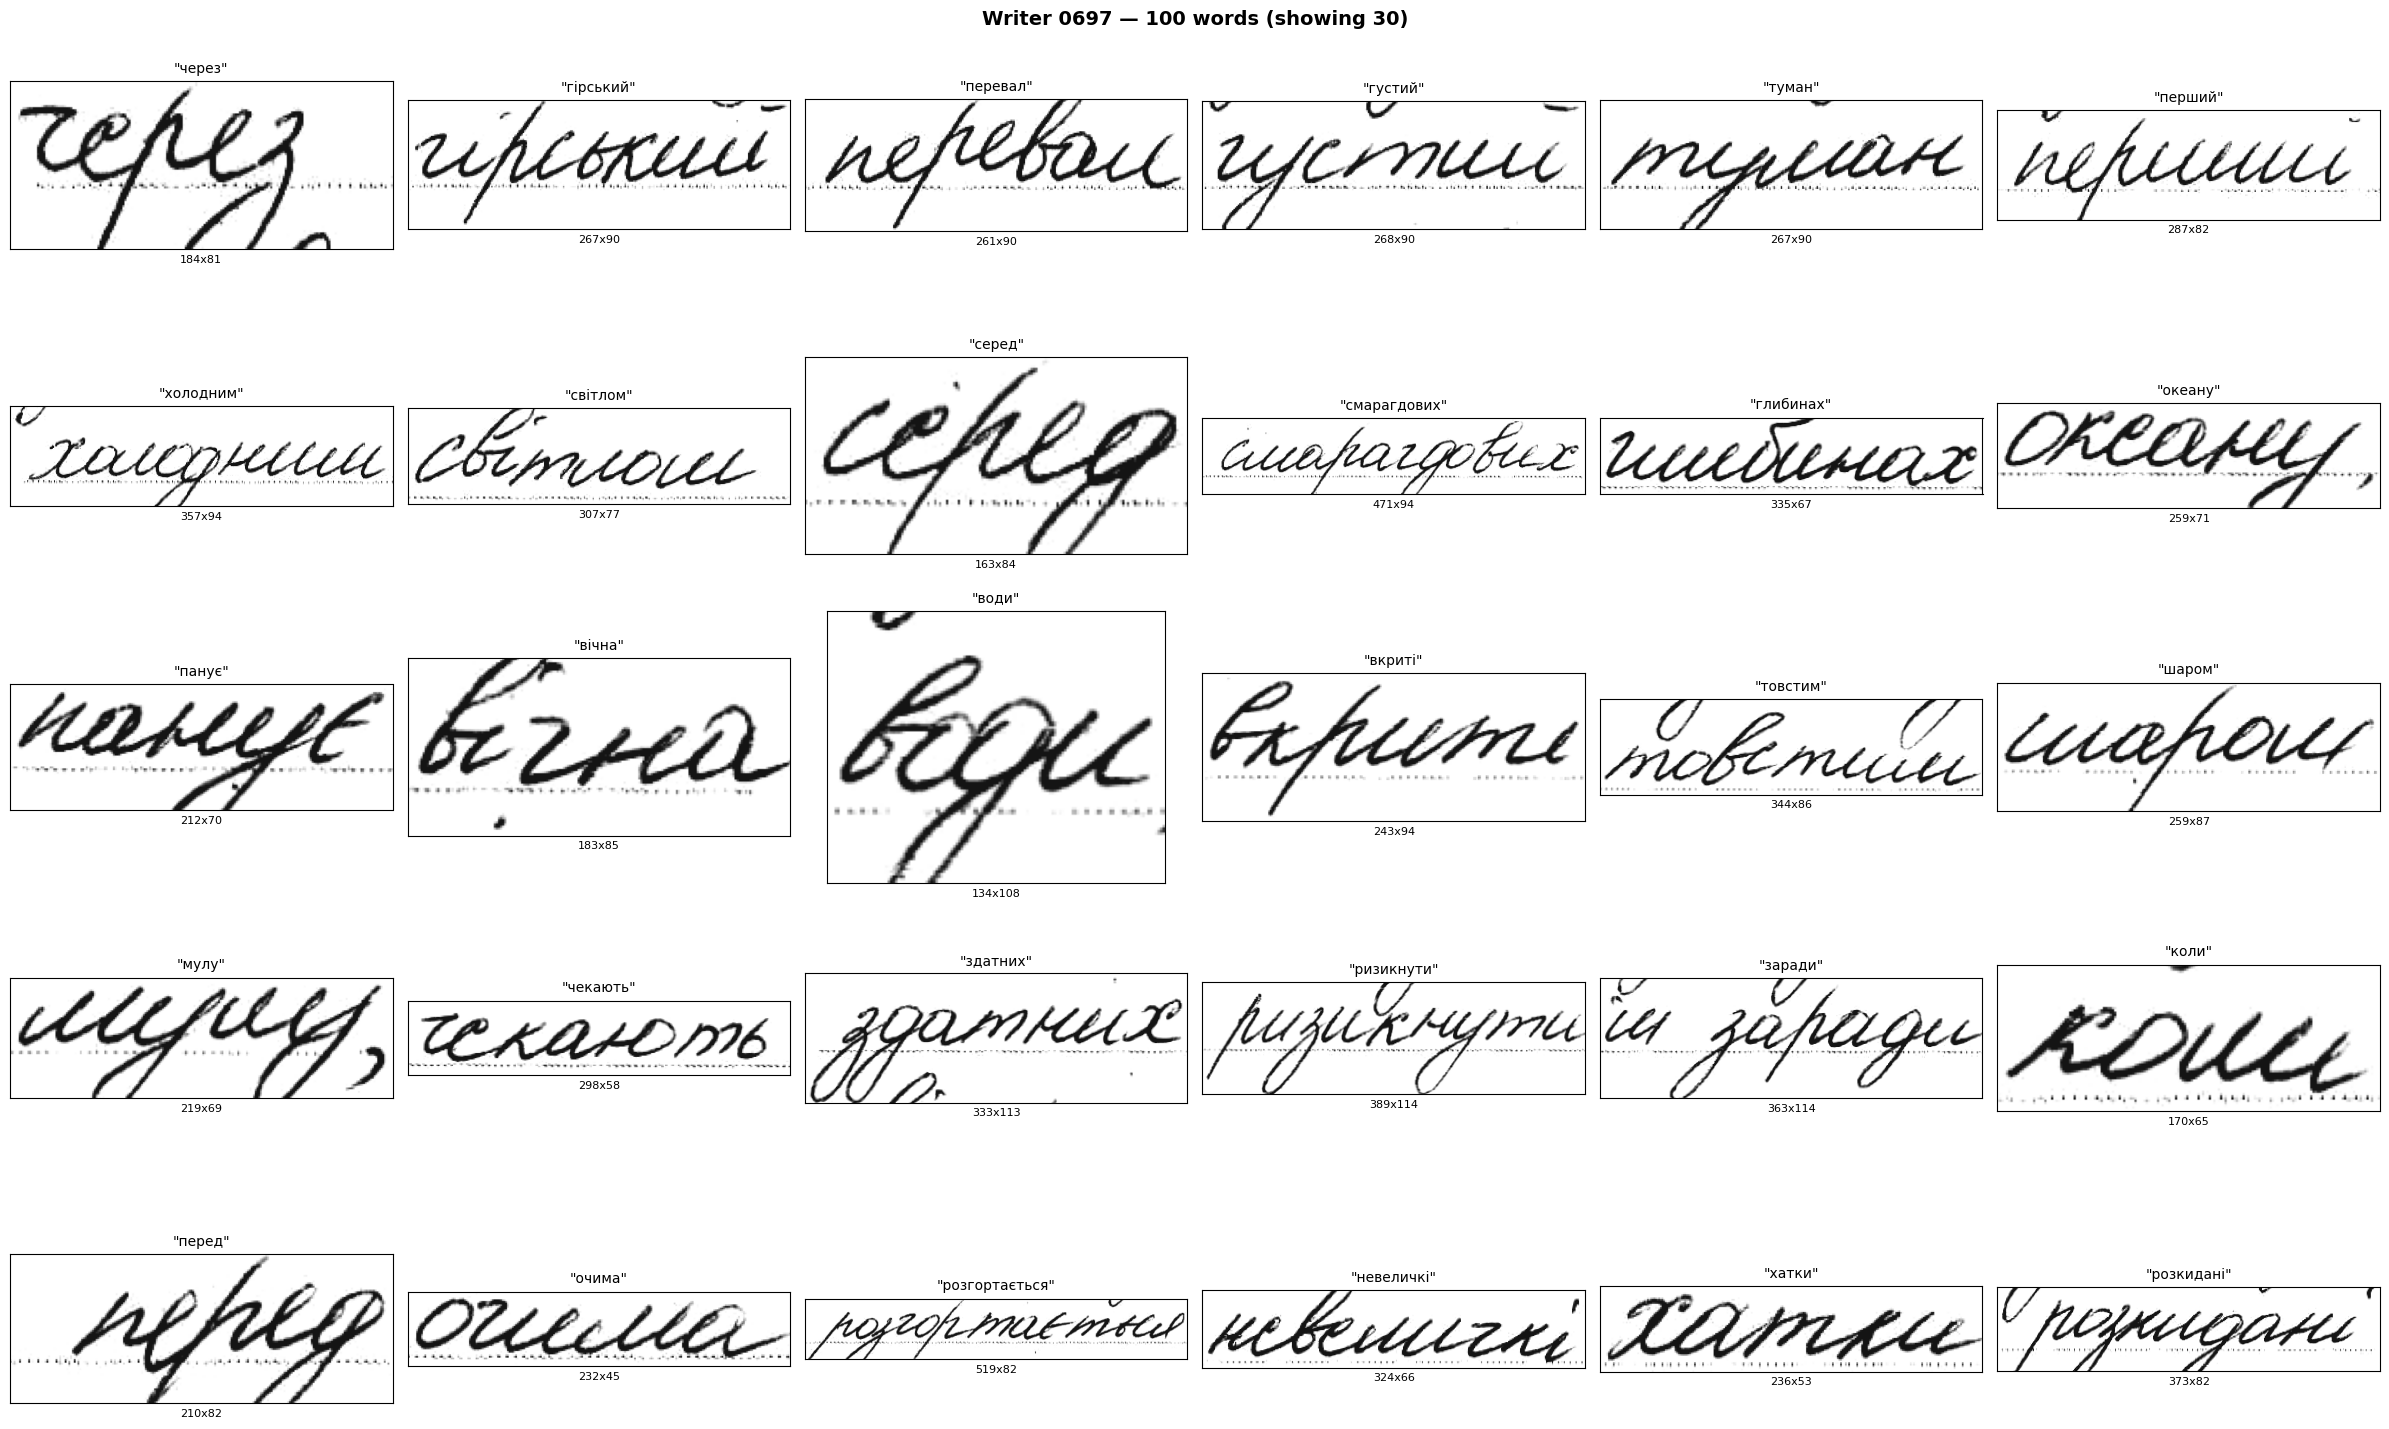

In [11]:
CHECK_WRITER = chosen[0]  # change to e.g. "0023"
MAX_SHOW = 30
COLS = 6

subset = df[df["writer"] == CHECK_WRITER]
sample = subset.head(MAX_SHOW)
rows = (len(sample) + COLS - 1) // COLS

fig, axes = plt.subplots(rows, COLS, figsize=(4 * COLS, 3 * rows))
axes = axes.flatten() if rows > 1 else (axes if COLS > 1 else [axes])

fig.suptitle(f"Writer {CHECK_WRITER} — {len(subset)} words (showing {len(sample)})",
             fontsize=14, fontweight="bold")

for i, (_, row) in enumerate(sample.iterrows()):
    img = Image.open(os.path.join(IMG_DIR, row["filename"]))
    axes[i].imshow(img, cmap="gray" if img.mode == "L" else None)
    axes[i].set_title(f'"{row["transcription"]}"', fontsize=10)
    axes[i].set_xlabel(f"{img.size[0]}x{img.size[1]}", fontsize=8)
    axes[i].set_xticks([])
    axes[i].set_yticks([])

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## Label Length Distribution

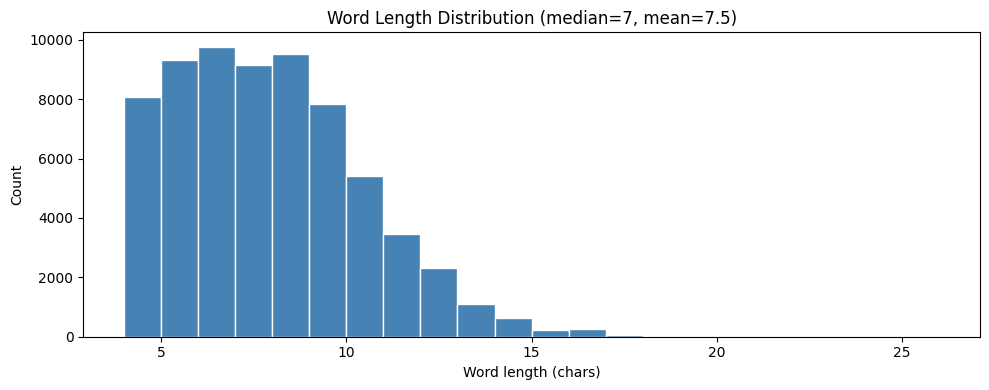

In [5]:
lengths = df["transcription"].str.len()
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(lengths, bins=range(4, lengths.max() + 2), color="steelblue", edgecolor="white")
ax.set_xlabel("Word length (chars)")
ax.set_ylabel("Count")
ax.set_title(f"Word Length Distribution (median={lengths.median():.0f}, mean={lengths.mean():.1f})")
plt.tight_layout()
plt.show()

## Image Dimensions

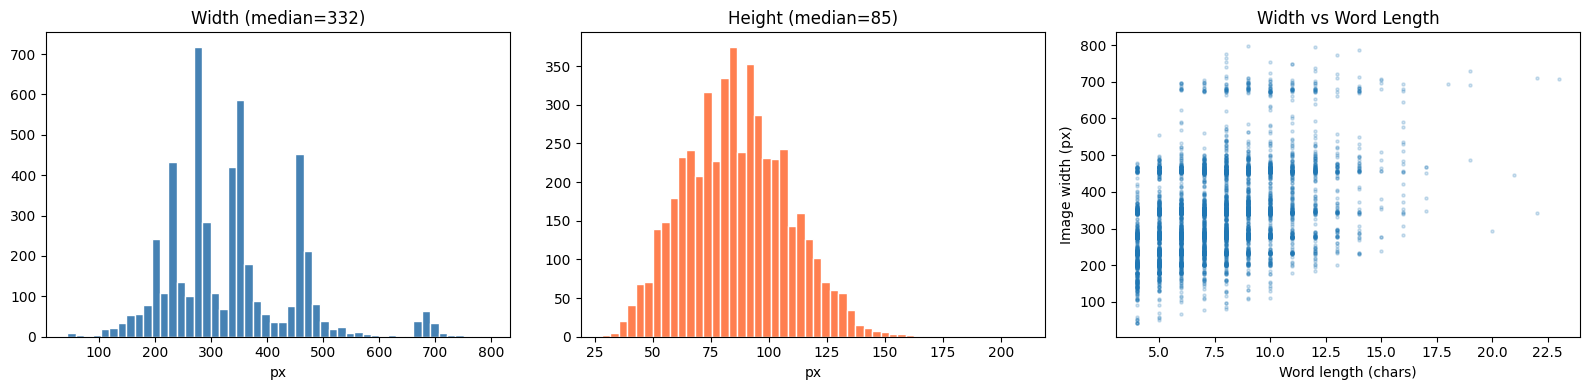

In [6]:
sample_n = min(5000, len(df))
sample_df = df.sample(n=sample_n, random_state=42)
dims = []
for fn in sample_df["filename"].values:
    img = Image.open(os.path.join(IMG_DIR, fn))
    dims.append((img.size[0], img.size[1], len(sample_df[sample_df['filename']==fn]['transcription'].values[0])))

widths, heights, char_lens = zip(*dims)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(widths, bins=50, color="steelblue", edgecolor="white")
axes[0].set_title(f"Width (median={np.median(widths):.0f})")
axes[0].set_xlabel("px")

axes[1].hist(heights, bins=50, color="coral", edgecolor="white")
axes[1].set_title(f"Height (median={np.median(heights):.0f})")
axes[1].set_xlabel("px")

axes[2].scatter(char_lens, widths, alpha=0.2, s=5)
axes[2].set_xlabel("Word length (chars)")
axes[2].set_ylabel("Image width (px)")
axes[2].set_title("Width vs Word Length")

plt.tight_layout()
plt.show()